In [208]:
import xgboost as xgb
from xgboost import XGBClassifier
import catboost
from catboost import Pool, CatBoostClassifier
from catboost.utils import get_confusion_matrix

In [209]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

In [471]:
from sklearn import tree
from sklearn import model_selection
from sklearn.linear_model import LinearRegression
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import mean_absolute_error
from sklearn.metrics import roc_auc_score
from sklearn.metrics import f1_score
from sklearn.metrics import make_scorer
from sklearn.metrics import silhouette_score
from sklearn.metrics import calinski_harabasz_score
from sklearn.metrics import davies_bouldin_score
from sklearn.metrics import homogeneity_score
from sklearn.metrics import completeness_score
from sklearn.metrics import adjusted_rand_score
from sklearn.model_selection import GridSearchCV
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.ensemble import AdaBoostClassifier
from sklearn.ensemble import AdaBoostRegressor
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.ensemble import StackingClassifier
from sklearn.cluster import KMeans
from sklearn.cluster import DBSCAN
from sklearn.cluster import AgglomerativeClustering
from sklearn.mixture import GaussianMixture
from sklearn.decomposition import TruncatedSVD
from sklearn.manifold import TSNE
from sklearn.decomposition import PCA

# Бустинг

In [39]:
# работает через direct_url
standart_url = 'https://drive.google.com/file/d/1AUkzlUCbBKgj-whxLxxBUIs28FUcxYJa/view?usp=drive_link'
direct_url = 'https://drive.google.com/uc?export=view&id=1AUkzlUCbBKgj-whxLxxBUIs28FUcxYJa'

data_load = pd.read_csv(direct_url)

In [40]:
df = data_load.copy()
df.head()

,Unnamed: 0,id,Gender,Customer Type,Age,Type of Travel,Class,Flight Distance,Inflight wifi service,Departure/Arrival time convenient,...,Inflight entertainment,On-board service,Leg room service,Baggage handling,Checkin service,Inflight service,Cleanliness,Departure Delay in Minutes,Arrival Delay in Minutes,satisfaction
0,0,70172,Male,Loyal Customer,13,Personal Travel,Eco Plus,460,3,4,...,5,4,3,4,4,5,5,25,18.0,neutral or dissatisfied
1,1,5047,Male,disloyal Customer,25,Business travel,Business,235,3,2,...,1,1,5,3,1,4,1,1,6.0,neutral or dissatisfied
2,2,110028,Female,Loyal Customer,26,Business travel,Business,1142,2,2,...,5,4,3,4,4,4,5,0,0.0,satisfied
3,3,24026,Female,Loyal Customer,25,Business travel,Business,562,2,5,...,2,2,5,3,1,4,2,11,9.0,neutral or dissatisfied
4,4,119299,Male,Loyal Customer,61,Business travel,Business,214,3,3,...,3,3,4,4,3,3,3,0,0.0,satisfied


In [41]:
df.shape

(103904, 25)

In [42]:
df['satisfaction'].describe()

count                      103904
unique                          2
top       neutral or dissatisfied
freq                        58879
Name: satisfaction, dtype: object

In [43]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 103904 entries, 0 to 103903
Data columns (total 25 columns):
 #   Column                             Non-Null Count   Dtype  
---  ------                             --------------   -----  
 0   Unnamed: 0                         103904 non-null  int64  
 1   id                                 103904 non-null  int64  
 2   Gender                             103904 non-null  object 
 3   Customer Type                      103904 non-null  object 
 4   Age                                103904 non-null  int64  
 5   Type of Travel                     103904 non-null  object 
 6   Class                              103904 non-null  object 
 7   Flight Distance                    103904 non-null  int64  
 8   Inflight wifi service              103904 non-null  int64  
 9   Departure/Arrival time convenient  103904 non-null  int64  
 10  Ease of Online booking             103904 non-null  int64  
 11  Gate location                      1039

In [44]:
df = df.drop(columns='Unnamed: 0')

In [45]:
df.isna().sum().sum()

310

In [46]:
df.columns

Index(['id', 'Gender', 'Customer Type', 'Age', 'Type of Travel', 'Class',
       'Flight Distance', 'Inflight wifi service',
       'Departure/Arrival time convenient', 'Ease of Online booking',
       'Gate location', 'Food and drink', 'Online boarding', 'Seat comfort',
       'Inflight entertainment', 'On-board service', 'Leg room service',
       'Baggage handling', 'Checkin service', 'Inflight service',
       'Cleanliness', 'Departure Delay in Minutes', 'Arrival Delay in Minutes',
       'satisfaction'],
      dtype='object')

In [47]:
# Задание 6.2

df['Arrival Delay in Minutes'] = df['Arrival Delay in Minutes'].fillna(df['Arrival Delay in Minutes'].median())
df['Arrival Delay in Minutes'].mean()

15.133392362180475

In [48]:
df['Arrival Delay in Minutes'].describe()

count    103904.000000
mean         15.133392
std          38.649776
min           0.000000
25%           0.000000
50%           0.000000
75%          13.000000
max        1584.000000
Name: Arrival Delay in Minutes, dtype: float64

<Axes: ylabel='Arrival Delay in Minutes'>

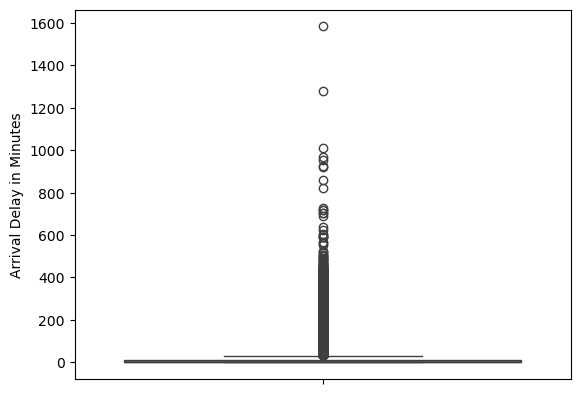

In [49]:
sns.boxplot(df['Arrival Delay in Minutes'])

<Axes: xlabel='satisfaction', ylabel='Count'>

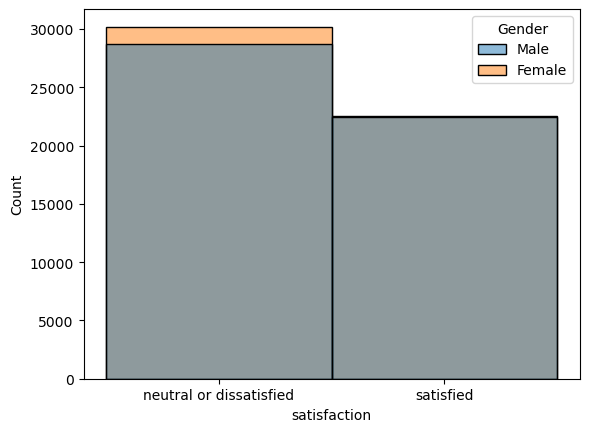

In [50]:
sns.histplot(
    data=df,
    x=df['satisfaction'],
    hue=df['Gender'],
)

In [51]:
# sns.pairplot(df);

In [52]:
# sns.pairplot(
#     data=df, 
#     aspect=.85,
#     hue='satisfaction'); # hue='cat_col' подсвечивает указанную категорию другим цветом.

In [53]:
# Задание 6.3

# 1.

df.groupby('Gender')['satisfaction'].value_counts() / df.shape[0]

Gender  satisfaction           
Female  neutral or dissatisfied    0.290586
        satisfied                  0.216873
Male    neutral or dissatisfied    0.276082
        satisfied                  0.216459
Name: count, dtype: float64

In [54]:
# 2.

df.groupby('Type of Travel')['satisfaction'].value_counts() / df.shape[0]

Type of Travel   satisfaction           
Business travel  satisfied                  0.401775
                 neutral or dissatisfied    0.287852
Personal Travel  neutral or dissatisfied    0.278815
                 satisfied                  0.031558
Name: count, dtype: float64

In [55]:
# 3.

df.groupby('Class')['satisfaction'].value_counts() / df.shape[0]

Class     satisfaction           
Business  satisfied                  0.331845
          neutral or dissatisfied    0.146145
Eco       neutral or dissatisfied    0.366146
          satisfied                  0.083741
Eco Plus  neutral or dissatisfied    0.054377
          satisfied                  0.017747
Name: count, dtype: float64

Перекодируем часть бинарных признаков, чтобы использовать их при обучении:


In [56]:
df['satisfaction'] = df['satisfaction'].map({'neutral or dissatisfied':0 , 'satisfied':1})
df['Customer Type'] = df['Customer Type'].map({'Loyal Customer':1, 'disloyal Customer':0})
df['Type of Travel'] = df['Type of Travel'].map({'Personal Travel':0, 'Business travel':1})
df['Gender'] = df['Gender'].map({'Male': 0, 'Female': 1})

In [57]:
# Задание 6.4

df=pd.get_dummies(df)
df.shape

(103904, 26)

In [58]:
# делим выборку на фичи и таргет
target = 'satisfaction'
y = df[target]
X = df.drop(columns=target)

In [59]:
# Задание 6.5

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, random_state=26)
y_test.shape

(20781,)

**Задание 6.6**

Теперь нам необходимо реализовать масштабирование данных. Для этого обучите на обучающей выборке метод StandardScaler() и с помощью него преобразуйте и обучающую, и тестовую выборки. Не забудьте, что целевую переменную обрабатывать не нужно.

Примечание. Отметим, что если бы дальше мы работали только с деревьями, масштабирование бы не требовалось. Однако мы реализуем его, чтобы можно было обучать и другие модели и сравнивать полученные результаты.

В качестве ответа введите самое первое значение из матрицы преобразованных признаков тестовой выборки. Округлите значение до двух знаков после точки-разделителя.

In [60]:
# Задание 6.6

scaler = StandardScaler()
scaler.fit(X_train) 
X_train = scaler.transform(X_train) 
X_test = scaler.transform(X_test) 
X_test[0][0]

0.9408251379303

In [61]:
X_test

array([[ 0.94082514, -1.0182236 ,  0.47381845, ...,  1.04624209,
        -0.90523003, -0.27897268],
       [-0.86687265,  0.98210256,  0.47381845, ...,  1.04624209,
        -0.90523003, -0.27897268],
       [-1.63303947,  0.98210256, -2.11051299, ..., -0.95580173,
         1.10469159, -0.27897268],
       ...,
       [ 1.52620083, -1.0182236 , -2.11051299, ..., -0.95580173,
         1.10469159, -0.27897268],
       [-0.60330678, -1.0182236 ,  0.47381845, ..., -0.95580173,
         1.10469159, -0.27897268],
       [ 1.34108544, -1.0182236 ,  0.47381845, ...,  1.04624209,
        -0.90523003, -0.27897268]])

**Задание 6.7**

Перейдём к обучению моделей. В качестве первой модели возьмём самую простую — логистическую регрессию. Мы делаем это для того, чтобы потом сравнивать с ней полученные результаты: так вы сможете выяснить, насколько ансамбли смогут улучшить точность прогноза.

Обучите логистическую регрессию с параметрами по умолчанию на наших данных. В качестве ответа введите значение метрики f1_score. Ответ округлите до трёх знаков после точки-разделителя.

In [62]:
# Задание 6.7

model_lr = LogisticRegression()
model_lr.fit(X_train, y_train)
preds_test = model_lr.predict(X_test)
f1_score(preds_test, y_test)

0.8547046934650797

**Задание 6.8**

Теперь перейдём к бустингу. Начнём с обучения первой модели — AdaBoost. В качестве базовой модели для неё возьмите решающее дерево с параметром random_state = 26.

Обучите AdaBoost, зафиксировав random_state со значением 26 и задав темп обучения 0.01. В качестве ответа введите значение метрики f1_score. Ответ округлите до трёх знаков после точки-разделителя.

In [63]:
# Задание 6.8

model_ada = AdaBoostClassifier(DecisionTreeClassifier(random_state=26),random_state=26,learning_rate=0.01)

model_ada.fit(X_train, y_train)
preds_test = model_ada.predict(X_test)
f1_score(preds_test, y_test)

0.9404794558121674

**Задание 6.9**

Перейдем к следующему алгоритму — градиентному бустингу.

Будем настраивать количество деревьев и темп обучения, делая перебор по следующей сетке:

```params = {"n_estimators":2**np.arange(8), "learning_rate":0.1**np.arange(3)}```

Используйте для поиска оптимальных параметров GridSearchCV, а для ускорения работы алгоритма задайте параметр кросс-валидации, равный 3.

Какое наибольшее значение метрики f1_score получилось? Ответ округлите до трёх знаков после точки-разделителя.

Примечание. Необходимо указать лучший результат в методе GridSearchCV на тренировочных данных.

In [64]:
# Задание 6.9

model_for_gs = GradientBoostingClassifier()
params = {"n_estimators":2**np.arange(8), "learning_rate":0.1**np.arange(3)}
gs = GridSearchCV(model_for_gs, 
                  params, 
                  cv=3, 
                  scoring=make_scorer(f1_score),
                  verbose=5,
                 )
 
gs.fit(X_train, y_train)

Fitting 3 folds for each of 24 candidates, totalling 72 fits
[CV 1/3] END .learning_rate=1.0, n_estimators=1;, score=0.873 total time=   0.0s
[CV 2/3] END .learning_rate=1.0, n_estimators=1;, score=0.870 total time=   0.0s
[CV 3/3] END .learning_rate=1.0, n_estimators=1;, score=0.871 total time=   0.0s
[CV 1/3] END .learning_rate=1.0, n_estimators=2;, score=0.880 total time=   0.1s
[CV 2/3] END .learning_rate=1.0, n_estimators=2;, score=0.878 total time=   0.1s
[CV 3/3] END .learning_rate=1.0, n_estimators=2;, score=0.875 total time=   0.2s
[CV 1/3] END .learning_rate=1.0, n_estimators=4;, score=0.901 total time=   0.4s
[CV 2/3] END .learning_rate=1.0, n_estimators=4;, score=0.896 total time=   0.4s
[CV 3/3] END .learning_rate=1.0, n_estimators=4;, score=0.897 total time=   0.4s
[CV 1/3] END .learning_rate=1.0, n_estimators=8;, score=0.920 total time=   0.8s
[CV 2/3] END .learning_rate=1.0, n_estimators=8;, score=0.920 total time=   0.8s
[CV 3/3] END .learning_rate=1.0, n_estimators=8;

,estimator,GradientBoostingClassifier()
,param_grid,"{'learning_rate': array([1. , 0.1 , 0.01]), 'n_estimators': array([ 1, ..., dtype=int32)}"
,scoring,make_scorer(f...hod='predict')
,n_jobs,None
,refit,True
,cv,3
,verbose,5
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,loss,'log_loss'


In [65]:
print("Лучшие гиперпараметры:", gs.best_params_)
print("Лучшее значение метрики:", gs.best_score_)

Лучшие гиперпараметры: {'learning_rate': 1.0, 'n_estimators': 128}
Лучшее значение метрики: 0.9491242985338658


In [66]:
# Задание 6.10

model_xgb = XGBClassifier(random_state=26)
model_xgb.fit(X_train,y_train)
preds_test = model_xgb.predict(X_test)
f1_score(preds_test, y_test)

0.9573723114544546

In [67]:
# Задание 6.11

model = CatBoostClassifier(random_state=26)
model.fit(X_train, y_train)
preds_class = model.predict(X_test)

Learning rate set to 0.068023
0:	learn: 0.6018151	total: 196ms	remaining: 3m 15s
1:	learn: 0.5020758	total: 208ms	remaining: 1m 43s
2:	learn: 0.4472471	total: 221ms	remaining: 1m 13s
3:	learn: 0.4028689	total: 233ms	remaining: 57.9s
4:	learn: 0.3674734	total: 244ms	remaining: 48.6s
5:	learn: 0.3397847	total: 255ms	remaining: 42.3s
6:	learn: 0.3121211	total: 266ms	remaining: 37.7s
7:	learn: 0.2917500	total: 277ms	remaining: 34.3s
8:	learn: 0.2749040	total: 287ms	remaining: 31.6s
9:	learn: 0.2575190	total: 299ms	remaining: 29.6s
10:	learn: 0.2473691	total: 309ms	remaining: 27.8s
11:	learn: 0.2377533	total: 320ms	remaining: 26.3s
12:	learn: 0.2279311	total: 331ms	remaining: 25.1s
13:	learn: 0.2212511	total: 342ms	remaining: 24.1s
14:	learn: 0.2100357	total: 354ms	remaining: 23.2s
15:	learn: 0.2025732	total: 365ms	remaining: 22.4s
16:	learn: 0.1942300	total: 384ms	remaining: 22.2s
17:	learn: 0.1877937	total: 395ms	remaining: 21.6s
18:	learn: 0.1832380	total: 407ms	remaining: 21s
19:	learn:

In [68]:
f1_score(preds_class, y_test)

0.9604136550650506

In [69]:
# Задание 6.12

cm = get_confusion_matrix(model, Pool(X_train, y_train))

In [70]:
cm

array([[46647.,   559.],
       [ 1273., 34644.]])

In [71]:
cm.sum()

83123.0

In [72]:
cm_percent = cm / cm.sum()

In [73]:
X_train.shape

(83123, 25)

<Axes: >

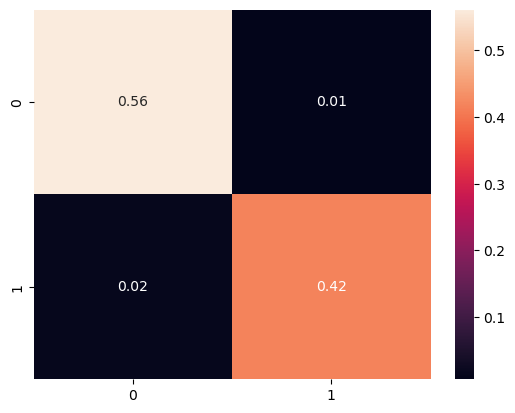

In [74]:
sns.heatmap(cm_percent, annot=True, fmt=".2f")

In [75]:
# Задание 6.13

pd.DataFrame(
    {
        "feature_importance": model.get_feature_importance(),
        "feature_names": df.drop(columns="satisfaction").columns,
    }
).sort_values(by=["feature_importance"], ascending=False)

,feature_importance,feature_names
6,26.001691,Inflight wifi service
4,17.854438,Type of Travel
11,7.582693,Online boarding
2,7.291082,Customer Type
22,5.334009,Class_Business
17,3.935882,Checkin service
16,3.675108,Baggage handling
3,3.653960,Age
9,3.537978,Gate location
18,2.840194,Inflight service


# Stacking

Мы будем работать с данными, которые содержат информацию о звуках, издаваемых лягушками, и характеристики этих звуков.

Необходимо классифицировать семейства лягушек в зависимости от особенностей их кваканья и прочих звуковых эффектов.

Будем решать задачу бинарной классификации по выявлению лягушек, которые относятся к семейству 'Dendrobatidae' (признак 'Family'). Семейство 'Dendrobatidae' будет классом 1, все остальные семейства — классом 0.

In [76]:
# работает через direct_url
standart_url = 'https://drive.google.com/file/d/1hPtE5MVNYT_q8Wjbx6SE4lrdY3cDxgOi/view?usp=drive_link'
direct_url = 'https://drive.google.com/uc?export=view&id=1hPtE5MVNYT_q8Wjbx6SE4lrdY3cDxgOi'

data_load = pd.read_csv(direct_url)

In [77]:
df = data_load.copy()
df.head()

,MFCCs_ 1,MFCCs_ 2,MFCCs_ 3,MFCCs_ 4,MFCCs_ 5,MFCCs_ 6,MFCCs_ 7,MFCCs_ 8,MFCCs_ 9,MFCCs_10,...,MFCCs_17,MFCCs_18,MFCCs_19,MFCCs_20,MFCCs_21,MFCCs_22,Family,Genus,Species,RecordID
0,1.0,0.152936,-0.105586,0.200722,0.317201,0.260764,0.100945,-0.150063,-0.171128,0.124676,...,-0.108351,-0.077623,-0.009568,0.057684,0.118680,0.014038,Leptodactylidae,Adenomera,AdenomeraAndre,1
1,1.0,0.171534,-0.098975,0.268425,0.338672,0.268353,0.060835,-0.222475,-0.207693,0.170883,...,-0.090974,-0.056510,-0.035303,0.020140,0.082263,0.029056,Leptodactylidae,Adenomera,AdenomeraAndre,1
2,1.0,0.152317,-0.082973,0.287128,0.276014,0.189867,0.008714,-0.242234,-0.219153,0.232538,...,-0.050691,-0.023590,-0.066722,-0.025083,0.099108,0.077162,Leptodactylidae,Adenomera,AdenomeraAndre,1
3,1.0,0.224392,0.118985,0.329432,0.372088,0.361005,0.015501,-0.194347,-0.098181,0.270375,...,-0.136009,-0.177037,-0.130498,-0.054766,-0.018691,0.023954,Leptodactylidae,Adenomera,AdenomeraAndre,1
4,1.0,0.087817,-0.068345,0.306967,0.330923,0.249144,0.006884,-0.265423,-0.172700,0.266434,...,-0.048885,-0.053074,-0.088550,-0.031346,0.108610,0.079244,Leptodactylidae,Adenomera,AdenomeraAndre,1


In [78]:
df.columns

Index(['MFCCs_ 1', 'MFCCs_ 2', 'MFCCs_ 3', 'MFCCs_ 4', 'MFCCs_ 5', 'MFCCs_ 6',
       'MFCCs_ 7', 'MFCCs_ 8', 'MFCCs_ 9', 'MFCCs_10', 'MFCCs_11', 'MFCCs_12',
       'MFCCs_13', 'MFCCs_14', 'MFCCs_15', 'MFCCs_16', 'MFCCs_17', 'MFCCs_18',
       'MFCCs_19', 'MFCCs_20', 'MFCCs_21', 'MFCCs_22', 'Family', 'Genus',
       'Species', 'RecordID'],
      dtype='object')

In [79]:
X = df.drop(columns=['Family', 'Genus', 'Species', 'RecordID'])

In [80]:
df['Family'].value_counts()

Family
Leptodactylidae    4420
Hylidae            2165
Dendrobatidae       542
Bufonidae            68
Name: count, dtype: int64

In [81]:
y = (df['Family'] == 'Dendrobatidae').astype(int)

In [82]:
y.describe()

count    7195.000000
mean        0.075330
std         0.263942
min         0.000000
25%         0.000000
50%         0.000000
75%         0.000000
max         1.000000
Name: Family, dtype: float64

In [83]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, random_state=31)

In [84]:
Y_train, Y_test = y_train, y_test

**Задание 7.5**

Для начала обучите на наших данных случайный лес с десятью решающими деревьями. Воспользуйтесь параметрами по умолчанию. В качестве значения random_state возьмите число 42.

Оцените значение $F_1$-меры и введите его в качестве ответа, предварительно округлив до двух знаков после точки-разделителя.

In [85]:
# Задание 7.5

model_rfc = RandomForestClassifier(10, random_state=42)
model_rfc.fit(X_train, Y_train)
pred = model_rfc.predict(X_test)
f1_score(Y_test, pred)

0.9726775956284153

**Задание 7.6**

Теперь попробуем улучшить качество нашего предсказания за счёт использования стекинга.

В качестве базовых моделей выберите следующие:

* случайный лес с десятью деревьями, random_state = 31;
* KNN, количество соседей = 11;
* наивный байесовский классификатор с параметрами по умолчанию, в качестве метода возьмите GaussianNB().
В качестве метамодели выберите логистическую регрессию.

Обучите модели и сделайте предсказание целевой метки для тестового набора данных.

Рассчитайте $F_1$-меру для тестового набора данных и введите её в качестве ответа, предварительно округлив до двух знаков после точки-разделителя.

In [88]:
# Задание 7.6

estimators = [('rf', RandomForestClassifier(n_estimators=10, random_state=31)),
              ('knn', KNeighborsClassifier(n_neighbors= 11)),
              ('nb', GaussianNB() )               
]
metamodel = StackingClassifier(
    estimators=estimators, final_estimator=LogisticRegression()
)
metamodel.fit(X_train, Y_train)
pred = metamodel.predict(X_test)
f1_score(Y_test, pred)

0.989247311827957

# 4/10   K-Means и EM-алгоритм

In [211]:
# работает через direct_url
standart_url = 'https://drive.google.com/file/d/1yiTDOBY6W2OiCwO2S0an7uKSbUaFGZ9L/view?usp=drive_link'
direct_url = 'https://drive.google.com/uc?export=view&id=1yiTDOBY6W2OiCwO2S0an7uKSbUaFGZ9L'

data_load = pd.read_csv(direct_url)

In [322]:
df = data_load.copy()
df.head()

,gradyear,gender,age,friends,basketball,football,soccer,softball,volleyball,swimming,...,blonde,mall,shopping,clothes,hollister,abercrombie,die,death,drunk,drugs
0,2006,M,18.982,7,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,2006,F,18.801,0,0,1,0,0,0,0,...,0,1,0,0,0,0,0,0,0,0
2,2006,M,18.335,69,0,1,0,0,0,0,...,0,0,0,0,0,0,0,1,0,0
3,2006,F,18.875,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,2006,NaN,18.995,10,0,0,0,0,0,0,...,0,0,2,0,0,0,0,0,1,1


In [323]:
df.isna().sum().head()

gradyear         0
gender        2724
age           5086
friends          0
basketball       0
dtype: int64

**Задание 4.1**

Мы будем реализовывать алгоритм только на признаках, которые заключают в себе ключевые слова, встречающиеся в сообщениях подростка. Удалите все остальные признаки. Какова размерность вашего текущего набора данных?



In [324]:
df = df.drop(columns=['gradyear', 'gender', 'age', 'friends',])
df.shape

(30000, 36)

**Задание 4.2**

Теперь нормализуйте данные с помощью StandardScaler(). Для получившейся матрицы нормализованных признаков выведите самое первое значение в самой первой строке (X_norm[0][0]). Ответ округлите до двух знаков после точки-разделителя.

In [325]:
X = df
scaler = StandardScaler()
scaler.fit(X) 
X_norm = scaler.transform(X) 
X_norm[0][0]

-0.3322172643985876

**Задание 4.3**

Реализуйте алгоритм k-means c девятью кластерами. В качестве значения параметра random_state возьмите число 42. Выведите получившееся значение инерции (model.inertia_). Ответ округлите до двух знаков после точки-разделителя.

In [326]:
# Задание 4.3

model = KMeans(n_clusters=9, random_state=42)
model.fit(X_norm)
model.inertia_

856276.696246804

In [327]:
# Задание 4.4
df_sns = df

df_sns.loc[:, 'label'] = model.labels_
df_sns.label.value_counts()

label
1    19599
2     4284
0     2201
4      941
3      902
5      851
8      754
7      467
6        1
Name: count, dtype: int64

**Задание 4.5**

1. Мы выделили девять кластеров, но, возможно, это далеко не оптимальное количество. Давайте попробуем применить разные методы для нахождения числа кластеров. Будем выбирать количество кластеров из диапазона от 3 до 9.

Для начала примените метод локтя. Каким в этом случае будет оптимальное число кластеров? Если оно не идентифицируется однозначно, запишите количество кластеров, при котором достигается наименьшая инерция.

In [328]:
def get_inertia(cluster_num, X):
    k_means =  KMeans(n_clusters=cluster_num, random_state=42)
    k_means.fit(X_norm)
    inertia = k_means.inertia_
    return inertia
 
inertia = []
for cluster_num in range(3, 10):
    inertia.append(get_inertia(cluster_num, X_norm))

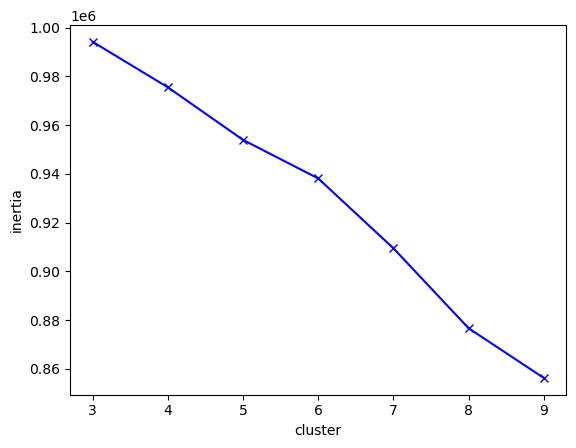

In [329]:
plt.xlabel("cluster")
plt.ylabel("inertia")
plt.plot([i for i in range(3, 10)], inertia, 'xb-');

In [330]:
def get_silhouette(cluster_num, X):
    k_means =  KMeans(n_clusters=cluster_num, random_state=42)
    k_means.fit(X)
    silhouette = silhouette_score(X, k_means.labels_, metric='euclidean')
    return silhouette

silhouettes = []
for i in range(3, 10):
    silhouettes.append(get_silhouette(i, X_norm))

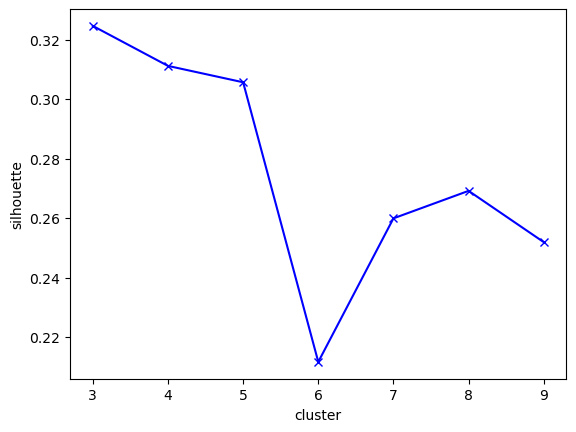

In [331]:
plt.xlabel("cluster")
plt.ylabel("silhouette")
plt.plot([i for i in range(3, 10)], silhouettes, 'xb-');

In [332]:
# Задание 4.4
df_sns = df

df_sns.loc[:, 'label'] = model.labels_
df_sns.label.value_counts()

label
1    19599
2     4284
0     2201
4      941
3      902
5      851
8      754
7      467
6        1
Name: count, dtype: int64

**Задание 4.6**

Мы будем использовать результаты, полученные в предыдущем задании с помощью коэффициента силуэта.

Реализуйте сегментацию подростков на выбранном количестве кластеров.

Для каждого кластера составьте топ-10 самых частых слов, назовём их ключевыми. Для этого сгруппируйте данные по кластерам, в каждом кластере вычислите среднее по каждому признаку, отсортируйте данные по убыванию и выделите первые 10 строк.

Найдите среди ключевых слов те, которые характерны для каждого кластера, то есть встречаются в каждом из них.

In [333]:
# Задание 4.6

top_list = []
for label, group in df.groupby('label'):
    means = group.iloc[:,:-1].mean().sort_values(ascending=False)
    top_5 = set(means.head(10).index)
    top_list.append(top_5)

set.intersection(*top_list)

{'god', 'hair'}

**Задание 4.7**

Итак, с k-means мы потренировались — теперь перейдём к EM-алгоритму.

Реализуйте EM-алгоритм (GaussianMixture) для такого же количества кластеров, как и в предыдущем задании. В качестве значения параметра random_state возьмите число 42.

Сколько подростков алгоритм отнёс к самому многочисленному кластеру?

In [335]:
# Задание 4.7 # не подходит к ответу на платформе

model = GaussianMixture(n_components=9, random_state=42)
predictions = model.fit_predict(X_norm)
np.unique(predictions, return_counts=True)

(array([0, 1, 2, 3, 4, 5, 6, 7, 8]),
 array([ 5669, 17261,  1263,  1658,   258,   804,     1,   626,  2460]))

**Задание 4.8**

В одном из кластеров, полученных с помощью алгоритма K-means, оказался всего один человек. Давайте узнаем, что это за подросток и чем он(а) интересуется.

Отметьте три слова, которые чаще всего встречаются в сообщениях этого подростка:

In [338]:
df[df['label'] == 6].T

,14187
basketball,0
football,2
soccer,0
softball,0
volleyball,0
swimming,1
cheerleading,0
baseball,0
tennis,0
sports,0


# 7/10   Итоговая практика по алгоритмам кластеризации


В нашем распоряжении есть данные о 8950 держателях кредитных карт одного из банков Нью-Йорка. Банк собрал достаточно много данных об этих людях и о том, как они пользовались кредитными картами за последние полгода.

Маркетологи хотят запустить рекламную кампанию, однако для этого необходимо произвести сегментацию клиентов, чтобы сделать акционное предложение более персонализированным. Мы попробуем использовать все известные нам методы кластеризации и посмотрим на получившиеся результаты.

In [339]:
# работает через direct_url
standart_url = 'https://drive.google.com/file/d/1g87nRNE1Oi_FnnVfB5h5dCsmYcSfswXW/view?usp=drive_link'
direct_url = 'https://drive.google.com/uc?export=view&id=1g87nRNE1Oi_FnnVfB5h5dCsmYcSfswXW'

data_load = pd.read_csv(direct_url)

In [340]:
df = data_load.copy()
df.head()

,CUST_ID,BALANCE,BALANCE_FREQUENCY,PURCHASES,ONEOFF_PURCHASES,INSTALLMENTS_PURCHASES,CASH_ADVANCE,PURCHASES_FREQUENCY,ONEOFF_PURCHASES_FREQUENCY,PURCHASES_INSTALLMENTS_FREQUENCY,CASH_ADVANCE_FREQUENCY,CASH_ADVANCE_TRX,PURCHASES_TRX,CREDIT_LIMIT,PAYMENTS,MINIMUM_PAYMENTS,PRC_FULL_PAYMENT,TENURE
0,C10001,40.900749,0.818182,95.40,0.00,95.4,0.000000,0.166667,0.000000,0.083333,0.000000,0,2,1000.0,201.802084,139.509787,0.000000,12
1,C10002,3202.467416,0.909091,0.00,0.00,0.0,6442.945483,0.000000,0.000000,0.000000,0.250000,4,0,7000.0,4103.032597,1072.340217,0.222222,12
2,C10003,2495.148862,1.000000,773.17,773.17,0.0,0.000000,1.000000,1.000000,0.000000,0.000000,0,12,7500.0,622.066742,627.284787,0.000000,12
3,C10004,1666.670542,0.636364,1499.00,1499.00,0.0,205.788017,0.083333,0.083333,0.000000,0.083333,1,1,7500.0,0.000000,NaN,0.000000,12
4,C10005,817.714335,1.000000,16.00,16.00,0.0,0.000000,0.083333,0.083333,0.000000,0.000000,0,1,1200.0,678.334763,244.791237,0.000000,12


In [342]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8950 entries, 0 to 8949
Data columns (total 18 columns):
 #   Column                            Non-Null Count  Dtype  
---  ------                            --------------  -----  
 0   CUST_ID                           8950 non-null   object 
 1   BALANCE                           8950 non-null   float64
 2   BALANCE_FREQUENCY                 8950 non-null   float64
 3   PURCHASES                         8950 non-null   float64
 4   ONEOFF_PURCHASES                  8950 non-null   float64
 5   INSTALLMENTS_PURCHASES            8950 non-null   float64
 6   CASH_ADVANCE                      8950 non-null   float64
 7   PURCHASES_FREQUENCY               8950 non-null   float64
 8   ONEOFF_PURCHASES_FREQUENCY        8950 non-null   float64
 9   PURCHASES_INSTALLMENTS_FREQUENCY  8950 non-null   float64
 10  CASH_ADVANCE_FREQUENCY            8950 non-null   float64
 11  CASH_ADVANCE_TRX                  8950 non-null   int64  
 12  PURCHA

In [343]:
df.describe()

,BALANCE,BALANCE_FREQUENCY,PURCHASES,ONEOFF_PURCHASES,INSTALLMENTS_PURCHASES,CASH_ADVANCE,PURCHASES_FREQUENCY,ONEOFF_PURCHASES_FREQUENCY,PURCHASES_INSTALLMENTS_FREQUENCY,CASH_ADVANCE_FREQUENCY,CASH_ADVANCE_TRX,PURCHASES_TRX,CREDIT_LIMIT,PAYMENTS,MINIMUM_PAYMENTS,PRC_FULL_PAYMENT,TENURE
count,8950.000000,8950.000000,8950.000000,8950.000000,8950.000000,8950.000000,8950.000000,8950.000000,8950.000000,8950.000000,8950.000000,8950.000000,8949.000000,8950.000000,8637.000000,8950.000000,8950.000000
mean,1564.474828,0.877271,1003.204834,592.437371,411.067645,978.871112,0.490351,0.202458,0.364437,0.135144,3.248827,14.709832,4494.449450,1733.143852,864.206542,0.153715,11.517318
std,2081.531879,0.236904,2136.634782,1659.887917,904.338115,2097.163877,0.401371,0.298336,0.397448,0.200121,6.824647,24.857649,3638.815725,2895.063757,2372.446607,0.292499,1.338331
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,50.000000,0.000000,0.019163,0.000000,6.000000
25%,128.281915,0.888889,39.635000,0.000000,0.000000,0.000000,0.083333,0.000000,0.000000,0.000000,0.000000,1.000000,1600.000000,383.276166,169.123707,0.000000,12.000000
50%,873.385231,1.000000,361.280000,38.000000,89.000000,0.000000,0.500000,0.083333,0.166667,0.000000,0.000000,7.000000,3000.000000,856.901546,312.343947,0.000000,12.000000
75%,2054.140036,1.000000,1110.130000,577.405000,468.637500,1113.821139,0.916667,0.300000,0.750000,0.222222,4.000000,17.000000,6500.000000,1901.134317,825.485459,0.142857,12.000000
max,19043.138560,1.000000,49039.570000,40761.250000,22500.000000,47137.211760,1.000000,1.000000,1.000000,1.500000,123.000000,358.000000,30000.000000,50721.483360,76406.207520,1.000000,12.000000


**Задание 7.3**

Заполните все пропуски средними арифметическими для признаков. Каким будет среднее арифметическое для признака MINIMUM_PAYMENTS (если считать после заполнения пропущенных значений)? Округлите результат до двух знаков после точки-разделителя.

In [344]:
df.isna().sum().sum()

314

In [345]:
df.isna().sum()

CUST_ID                               0
BALANCE                               0
BALANCE_FREQUENCY                     0
PURCHASES                             0
ONEOFF_PURCHASES                      0
INSTALLMENTS_PURCHASES                0
CASH_ADVANCE                          0
PURCHASES_FREQUENCY                   0
ONEOFF_PURCHASES_FREQUENCY            0
PURCHASES_INSTALLMENTS_FREQUENCY      0
CASH_ADVANCE_FREQUENCY                0
CASH_ADVANCE_TRX                      0
PURCHASES_TRX                         0
CREDIT_LIMIT                          1
PAYMENTS                              0
MINIMUM_PAYMENTS                    313
PRC_FULL_PAYMENT                      0
TENURE                                0
dtype: int64

In [348]:
col_na = 'MINIMUM_PAYMENTS'
df[col_na] = df[col_na].fillna(df[col_na].mean())
col_na = 'CREDIT_LIMIT'
df[col_na] = df[col_na].fillna(df[col_na].mean())

In [349]:
df.isna().sum()

CUST_ID                             0
BALANCE                             0
BALANCE_FREQUENCY                   0
PURCHASES                           0
ONEOFF_PURCHASES                    0
INSTALLMENTS_PURCHASES              0
CASH_ADVANCE                        0
PURCHASES_FREQUENCY                 0
ONEOFF_PURCHASES_FREQUENCY          0
PURCHASES_INSTALLMENTS_FREQUENCY    0
CASH_ADVANCE_FREQUENCY              0
CASH_ADVANCE_TRX                    0
PURCHASES_TRX                       0
CREDIT_LIMIT                        0
PAYMENTS                            0
MINIMUM_PAYMENTS                    0
PRC_FULL_PAYMENT                    0
TENURE                              0
dtype: int64

In [350]:
df['MINIMUM_PAYMENTS'].mean()

864.2065423050827

**Задание 7.4**

Теперь нормализуйте данные с помощью StandardScaler(). Для получившейся матрицы нормализованных признаков выведите самое первое значение в самой первой строке (X_norm[0][0]). Округлите до двух знаков после точки-разделителя.

Не забудьте предварительно удалить признак CUST_ID — он не поможет при кластеризации, так как не несёт никакой содержательной информации.

In [351]:
df = df.drop(columns=['CUST_ID'])
df.shape

(8950, 17)

In [352]:
X = df
scaler = StandardScaler()
scaler.fit(X) 
X_norm = scaler.transform(X) 
X_norm[0][0]

-0.7319893664465486

**Задание 7.5**

Теперь можем приступать к кластеризации. Начнём с самого простого и популярного метода — k-means. Для того чтобы его применить, необходимо узнать число кластеров. Наилучший способ сделать это — применить коэффициент силуэта. Найдите с его помощью оптимальное количество кластеров, перебрав диапазон от 2 до 9 включительно. В этом и следующем заданиях для параметра random_state возьмём значение 42, параметр init='random'.

In [355]:
def get_silhouette(cluster_num, X):
    k_means =  KMeans(n_clusters=cluster_num, random_state=42, init='random')
    k_means.fit(X)
    silhouette = silhouette_score(X, k_means.labels_, metric='euclidean')
    return silhouette

silhouettes = []
for i in range(2, 10):
    silhouettes.append(get_silhouette(i, X_norm))

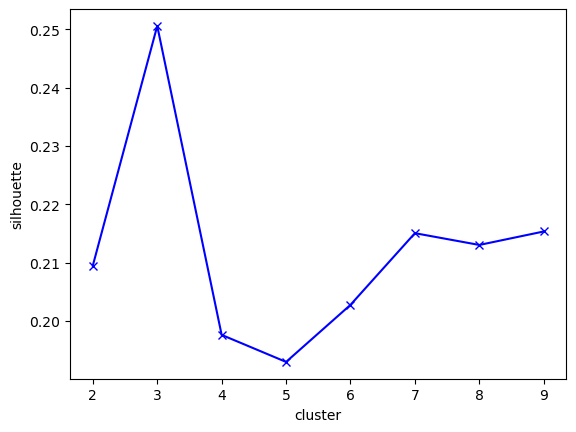

In [356]:
plt.xlabel("cluster")
plt.ylabel("silhouette")
plt.plot([i for i in range(2, 10)], silhouettes, 'xb-');

In [360]:
max(silhouettes)

0.25055570796307736

**Задание 7.6**

Теперь реализуем непосредственно кластеризацию k-means с оптимальным количеством кластеров, которое мы определили в предыдущем задании.

Сколько человек оказалось в самой малочисленной группе?

In [361]:
kmeans = KMeans(n_clusters=3, random_state=42, init='random')
kmeans.fit(X_norm)
df.loc[:, 'label'] = kmeans.labels_
df.label.value_counts()

label
2    6119
1    1596
0    1235
Name: count, dtype: int64

**Задание 7.7**

Попробуем применить DBSCAN. Для начала реализуйте его с параметрами по умолчанию.

Сколько кластеров было выделено?

In [364]:
# Задание 7.7

db = DBSCAN()
db.fit(X_norm)
clusters = db.labels_

In [367]:
clusters, len(clusters)

(array([ 0, -1, -1, ..., -1, -1, -1]), 8950)

In [366]:
len(set(clusters)) - (1 if -1 in clusters else 0)

38

In [368]:
db

,eps,0.5
,min_samples,5
,metric,'euclidean'
,metric_params,None
,algorithm,'auto'
,leaf_size,30
,p,None
,n_jobs,None


In [369]:
db.labels_

array([ 0, -1, -1, ..., -1, -1, -1])

**Задание 7.8**

В предыдущем задании получилось очень много кластеров. Возможно, это случилось потому, что мы взяли параметры по умолчанию, а результат алгоритма DBSCAN, как вы помните, очень чувствителен к ним.

Давайте попробуем с помощью цикла перебрать параметр eps по значениям, заданным как np.arange(0.1,3,0.2), а параметр min_samples — по значениям, заданным как range(1,20,4). Найдите комбинацию, которая даёт максимальное значение коэффициента силуэта.

In [370]:
# Задание 7.8

siliuette_list_dbscan = []
 
for eps in np.arange(0.1, 3, 0.2):
    for min_sample in range(1, 20, 4):
        dbscan = DBSCAN(eps=eps, min_samples=min_sample)
        dbscan.fit(X_norm)
        sil_score = silhouette_score(X_norm, dbscan.labels_, metric='euclidean')
        siliuette_list_dbscan.append((eps, min_sample, sil_score, len(set(dbscan.labels_))) )
df_dbscan = pd.DataFrame(siliuette_list_dbscan, columns=['eps', 'min_samples', 'sil_score', 'number_of_clusters'])
df_dbscan.sort_values(by = 'sil_score')

,eps,min_samples,sil_score,number_of_clusters
11,0.5,5,-0.443701,39
16,0.7,5,-0.438837,29
6,0.3,5,-0.424475,42
7,0.3,9,-0.404209,15
30,1.3,1,-0.399305,1536
...,...,...,...,...
74,2.9,17,0.591924,2
66,2.7,5,0.592182,2
73,2.9,13,0.595399,2
72,2.9,9,0.603811,2


**Задание 7.9**

Теперь давайте реализуем агломеративную иерархическую кластеризацию. Переберите количество кластеров в диапазоне от 3 до 9 включительно и найдите то их число, которое будет давать максимальный коэффициент силуэта.

In [373]:
# Задание 7.9

siliuette_list_hierarchical = []
 
for cluster in range(3, 10, 1):
        agglomerative = AgglomerativeClustering(metric='euclidean', n_clusters=cluster).fit_predict(X_norm)
        sil_score = silhouette_score(X_norm, agglomerative, metric='euclidean')
        siliuette_list_hierarchical.append((cluster, sil_score, len(set(agglomerative)) ) )
        
df_hierarchical = pd.DataFrame(siliuette_list_hierarchical, columns=['cluster', 'sil_score','number_of_clusters'])
 
df_hierarchical.sort_values(by = 'sil_score')

,cluster,sil_score,number_of_clusters
5,8,0.152035,8
6,9,0.153719,9
1,4,0.154709,4
4,7,0.156415,7
2,5,0.158069,5
0,3,0.173110,3
3,6,0.173356,6


**Задание 7.10**

Сколько будет наблюдений в самом многочисленном классе, если мы обучим на наших данных модель агломеративной иерархической кластеризации с количеством кластеров, полученным в предыдущем задании?

In [375]:
# Задание 7.10

model = AgglomerativeClustering(metric='euclidean', n_clusters=6).fit(X_norm)
df['cluster_id'] = model.labels_
df['cluster_id'].value_counts()

cluster_id
0    3946
1    2931
2     864
5     722
3     464
4      23
Name: count, dtype: int64

Давайте визуализируем результаты кластеризации k-means, отобразив два признака — количество покупок и кредитный лимит:


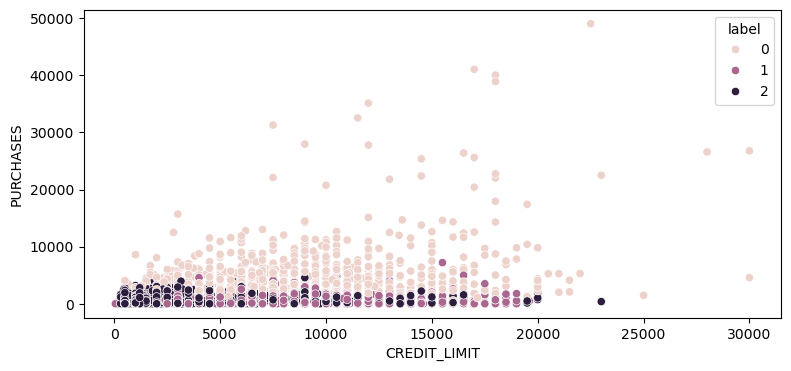

In [378]:
plt.figure(figsize=(9,4))
sns.scatterplot(data=df, x='CREDIT_LIMIT', y='PURCHASES', hue='label')
plt.show()

Мы видим, что практически все точки очень плотно сконцентрированы вместе, так что наши результаты с другими алгоритмами вполне предсказуемы.

С точки зрения интерпретации на графике явно выделяется группа тех, кто совершает много покупок по кредитной карте, и тех, кто совершает их меньше и имеет меньший кредитный лимит.

Но, разумеется, это лишь приблизительная интерпретация, ведь качественного разбиения с помощью большинства методов мы так и не получили, а кроме того, здесь мы видим лишь два признака из многих, на основе которых осуществлялась кластеризация.

Такая проблема с выделением кластеров часто возникает с данными, в которых много признаков. Для того чтобы её решить, можно, например, применять снижение размерности — в следующем модуле мы как раз поработаем с соответствующими методами и научимся преодолевать такие ситуации.

# 4/10   Меры качества кластеризации. Практика

✍ В двух предыдущих уроках мы познакомились с основными внутренними и внешними мерами, с помощью которых можно оценивать качество кластеризации. В этом уроке мы попрактикуемся в решении задач кластеризации и используем полученные знания, чтобы оценить результаты.

Мы будем использовать данные, взятые с датчиков акселерометров и гироскопов смартфонов Samsung Galaxy S3. Телефоны носили в кармане добровольцы в возрасте от 19 до 49 лет. Смартфоны постоянно фиксировали значения ускорения и скорости по трём измерениям, а поведение людей записывали на видео, чтобы вручную отметить, какую физическую активность осуществлял человек в тот или иной момент.

In [400]:
# https://drive.google.com/file/d/1Hz7tCpcWk2ThZYuN5b_6coCBeMPJa9tQ/view?usp=drive_link
# https://drive.google.com/file/d/1TbBd6XwRm9kwoSfvTMxMLLsbaKzSNcJI/view?usp=drive_link
# https://drive.google.com/file/d/1YwFDBOLZyW1WFjdU58zVmigFxlflA-bV/view?usp=drive_link
# https://drive.google.com/file/d/1_bpmxdP6_hcLG5TqEoNBXw22Rg7iqBtp/view?usp=drive_link


test_labels_txt = 'https://drive.google.com/uc?export=view&id=1Hz7tCpcWk2ThZYuN5b_6coCBeMPJa9tQ'
test_txt = 'https://drive.google.com/uc?export=view&id=1TbBd6XwRm9kwoSfvTMxMLLsbaKzSNcJI'
train_labels_txt = 'https://drive.google.com/uc?export=view&id=1YwFDBOLZyW1WFjdU58zVmigFxlflA-bV'
train_txt = 'https://drive.google.com/uc?export=view&id=1_bpmxdP6_hcLG5TqEoNBXw22Rg7iqBtp'


In [416]:
root_path = '/home/itj/Downloads/Physical Activity Data/'

X_train = np.loadtxt(root_path + 'train.txt')

X_test = np.loadtxt(root_path + 'test.txt')

y_train = np.loadtxt(root_path + 'train_labels.txt')
y_test = np.loadtxt(root_path + 'test_labels.txt')

X = np.concatenate((X_train, X_test))
y = np.concatenate((y_train, y_test))
X.shape

(10299, 561)

In [417]:
# Задание 4.2

len(np.unique(y))

6

**Задание 4.3**

Далее необходимо отмасштабировать признаки. Будем использовать для этого алгоритм StandardScaler. Примените его ко всем значениям признаков и впишите в качестве ответа значение первого признака для первого объекта, предварительно округлив его до двух знаков после точки-разделителя.

In [418]:
scaler = StandardScaler()
scaler.fit(X) 
X_norm = scaler.transform(X) 
X_norm[0][0]

0.2105338541767611

In [419]:
X_scaled = X_norm

**Задание 4.4**

Пора переходить к кластеризации. Для начала определите оптимальное количество кластеров, используя внутренние меры кластеризации. Используйте все известные вам коэффициенты, реализуемые в библиотеке sklearn: коэффициент силуэта, индекс Калински — Харабаса и индекс Дэвиса — Болдина. В качестве алгоритма возьмите k-means++, в качестве значения параметра random_state — число 42.

Выведите оптимальное количество кластеров для каждой метрики, перебирая значения от 2 до 9 включительно. Также введите значение каждой метрики, округлённое до двух знаков после точки-разделителя.

In [421]:
# Задание 4.4

#проходимся циклом по всем нужным нам значениям количества кластеров
for i in range(2,10):
	# обучаем модель k-means с текущим количеством кластеров
    km = KMeans(n_clusters = i, random_state = 42 ).fit(X_scaled)
	#предсказываем метки
    y_pred = km.labels_
	#выводим результат для коэффициента силуэта
    print (i, silhouette_score(X_scaled,  y_pred))
for i in range(2,10):
    km = KMeans(n_clusters = i , random_state = 42 ).fit(X_scaled)
    y_pred = km.labels_
    print (i, calinski_harabasz_score(X_scaled,y_pred))
for i in range(2,10):
    km = KMeans(n_clusters = i , random_state = 42 ).fit(X_scaled)
    y_pred = km.labels_
    print (i, davies_bouldin_score(X_scaled, y_pred))

2 0.39373247640770803
3 0.3165174060752722
4 0.27826450266863173
5 0.25967188010717684
6 0.11706978147952803
7 0.10120866778714624
8 0.09199222994561512
9 0.08267046481294246
2 7880.813903657111
3 5034.470017849821
4 3668.0173727083115
5 2845.838894164787
6 2504.6858590869924
7 2171.068983512932
8 1890.8900519769945
9 1685.013483142379
2 1.070744182238566
3 1.783820528813495
4 2.0464376750898374
5 2.266485003212644
6 2.5259990070249505
7 2.65028581558819
8 2.6190356338467886
9 2.7593862241965237


Возможно, вам покажется удивительным, что все три меры единодушно показали такое расхождение с реальным разделением на кластеры. Однако это совершенно не значит, что они показывают неверные значения или что алгоритмы кластеризации работают некорректно. Возможно, такое разделение на другое количество кластеров можно объяснить — вы сами увидите это позднее.

**Задание 4.5**

Теперь давайте оценим качество кластеризации с точки зрения внешних мер. Реализуйте кластеризацию с помощью классической версии алгоритма k-means. Пусть количество кластеров будет соответствовать количеству активностей. Задайте следующие значения параметров: random_state=42, init='random'.

В качестве ответов введите значения получившихся мер, предварительно округлив их до двух знаков после точки-разделителя.

In [426]:
# Задание 4.5

#определяем модель k-means
model= KMeans(n_clusters=6, init='random', random_state=42)
#обучаем модель
model.fit(X_scaled)
#вычисляем значение однородности
print(homogeneity_score(y, model.labels_))
#вычисляем значение полноты
print(completeness_score(y, model.labels_))
#вычисляем значение скорректированного индекса Рэнда
print(adjusted_rand_score(y, model.labels_))

0.5406994702303469
0.5792825031740629
0.41962042580459846


**Задание 4.6**

Выясните, к каким кластерам были преимущественно отнесены различные активности (т. е. в какой кластер попало большинство наблюдений с этой активностью). Нумерацию кластеров начинайте с 1.

Заметьте, что кластеры могут повторяться.

In [437]:
# Задание 4.6

#создаём таблицу сопряжённости
ct = pd.crosstab(y, model.labels_)
#определяем название активностей
ct.index = ['ходьба', 'подъём', 'спуск', 'сидение', 'стояние', 'лежание']
ct.columns = list(range(1,7))
ct

,1,2,3,4,5,6
ходьба,741,897,0,0,84,0
подъём,297,1236,2,0,9,0
спуск,882,310,0,0,214,0
сидение,0,1,447,91,0,1238
стояние,0,0,560,0,0,1346
лежание,0,5,329,1556,0,54


**Задание 4.7**

Теперь попробуйте реализовать алгоритм k-means для двух кластеров (для того числа активностей, которое является оптимальным с точки зрения внутренних мер) и снова посмотреть, как алгоритм разобьёт активности по кластерам. Как и в предыдущем задании, нумерацию кластеров начинайте с 1.

In [441]:
#определяем модель k-means
model = KMeans(n_clusters = 2, init='random', random_state=42)
#обучаем модель
model.fit(X_scaled)
#вычисляем значение однородности
print(homogeneity_score(y, model.labels_))
#вычисляем значение полноты
print(completeness_score(y, model.labels_))
#вычисляем значение скорректированного индекса Рэнда
print(adjusted_rand_score(y, model.labels_))

0.37797082246896085
0.9795305596996312
0.3296106738894193


In [449]:
# Задание 4.7

ctable = pd.crosstab(y, model.labels_)
ctable.index = ['ходьба', 'подъём', 
                'спуск', 'сидение', 'стояние', 'лежание']
ctable.columns = list(range(1,3))
ctable

,1,2
ходьба,1722,0
подъём,1536,8
спуск,1406,0
сидение,3,1774
стояние,0,1906
лежание,12,1932


In [451]:
# Задание 4.8

completeness_score(y, model.labels_)

0.9795305596996312

In [455]:
# Задание 4.10

ag = AgglomerativeClustering(n_clusters=2).fit(X_scaled)

In [456]:
print("Completeness: %0.3f", completeness_score(y, ag.labels_))

Completeness: %0.3f 0.9999999999999993


⭐ В этом уроке мы потренировались в решении задачи кластеризации. Мы смогли сравнить два алгоритма с точки зрения внешних мер, а также увидеть, что расхождение показателей внутренних мер с предполагаемым разделением на кластеры не всегда говорит о плохо реализованных алгоритмах кластеризации: несмотря на то что наши алгоритмы предложили разделение на два кластера, а не на шесть, оно было обосновано наблюдаемыми признаками и содержательно интерпретировалось. Поэтому, даже если у вас есть разметка и вы можете пользоваться внешними мерами, советуем не пренебрегать внутренними, так как это поможет лучше узнать ваши данные.

В следующих уроках мы познакомимся с алгоритмами снижения размерности. После этого предлагаем вам вернуться к данной задаче и попробовать улучшить качество кластеризации, уменьшив количество признаков.

# 7/10   Снижение размерности. Практика

In [458]:
# Задание 5.1

np.cov(np.array([3,4,1]),np.array([1,6,2])).sum()

14.333333333333334

In [462]:
df = pd.read_csv('data/Country-data.csv')
df

,country,child_mort,exports,health,imports,income,inflation,life_expec,total_fer,gdpp
0,Afghanistan,90.2,10.0,7.58,44.9,1610,9.44,56.2,5.82,553
1,Albania,16.6,28.0,6.55,48.6,9930,4.49,76.3,1.65,4090
2,Algeria,27.3,38.4,4.17,31.4,12900,16.10,76.5,2.89,4460
3,Angola,119.0,62.3,2.85,42.9,5900,22.40,60.1,6.16,3530
4,Antigua and Barbuda,10.3,45.5,6.03,58.9,19100,1.44,76.8,2.13,12200
...,...,...,...,...,...,...,...,...,...,...
162,Vanuatu,29.2,46.6,5.25,52.7,2950,2.62,63.0,3.50,2970
163,Venezuela,17.1,28.5,4.91,17.6,16500,45.90,75.4,2.47,13500
164,Vietnam,23.3,72.0,6.84,80.2,4490,12.10,73.1,1.95,1310
165,Yemen,56.3,30.0,5.18,34.4,4480,23.60,67.5,4.67,1310


In [465]:
# Задание 7.1

df.sort_values(by='life_expec')

,country,child_mort,exports,health,imports,income,inflation,life_expec,total_fer,gdpp
66,Haiti,208.0,15.3,6.91,64.7,1500,5.450,32.1,3.33,662
87,Lesotho,99.7,39.4,11.10,101.0,2380,4.150,46.5,3.30,1170
31,Central African Republic,149.0,11.8,3.98,26.5,888,2.010,47.5,5.21,446
166,Zambia,83.1,37.0,5.89,30.9,3280,14.000,52.0,5.40,1460
94,Malawi,90.5,22.8,6.59,34.9,1030,12.100,53.1,5.31,459
...,...,...,...,...,...,...,...,...,...,...
68,Iceland,2.6,53.4,9.40,43.3,38800,5.470,82.0,2.20,41900
7,Australia,4.8,19.8,8.73,20.9,41400,1.160,82.0,1.93,51900
145,Switzerland,4.5,64.0,11.50,53.3,55500,0.317,82.2,1.52,74600
133,Singapore,2.8,200.0,3.96,174.0,72100,-0.046,82.7,1.15,46600


In [467]:
# Задание 7.2
country_data = df
X = country_data.drop('country',axis =1)  
y = country_data['country']
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
X_scaled[0][0]

1.2915323778422956

<Axes: >

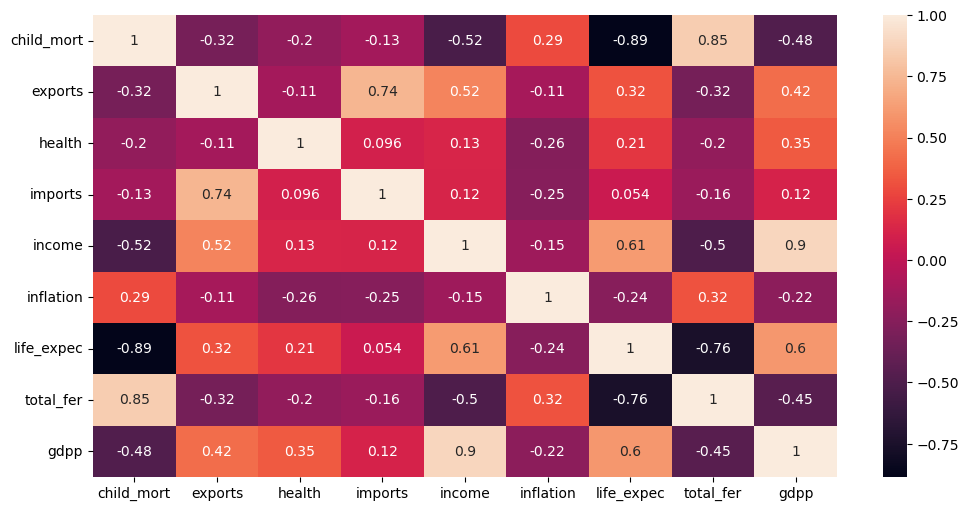

In [469]:
# Задание 7.3

X_scaled_df = pd.DataFrame(X_scaled,columns=X.columns)
plt.figure(figsize = (12,6))       
sns.heatmap(X_scaled_df.corr(),annot = True)

**Задание 7.4**

Теперь понизим размерность данных — возьмём для этого метод главных компонент (PCA) как самый простой и популярный.

Найдите минимальное число компонент, которые суммарно могут объяснить как минимум 90 % разброса данных.

In [472]:
# Задание 7.4

pca = PCA(n_components=0.9, random_state=42).fit(X_scaled)
len(pca.components_)

5

# Задание 7.5

Используйте главные компоненты, выделенные в предыдущем задании.

Какую долю дисперсии объясняет первая главная компонента? Ответ округлите до двух знаков после точки-разделителя.

In [474]:
# Задание 7.5

pca.explained_variance_ratio_[0]

0.45951739786095896

**Задание 7.6**

Как вы помните, при создании компонент с помощью PCA они должны получиться независимыми, то есть мы не должны теперь наблюдать высоких коэффициентов корреляции.

Постройте матрицу корреляций. Сколько значений в ней превышают , не считая единичных значений на главной диагонали?

<Axes: >

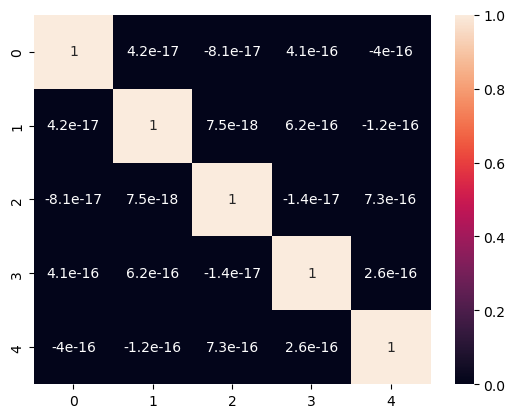

In [475]:
# Задание 7.6

X_pca = pca.fit_transform(X_scaled)
corrmat = np.corrcoef(X_pca.transpose())
sns.heatmap(corrmat, annot=True)

Как видим, даже самый большой коэффициент корреляции практически неотличим от нуля — это значит, что мы всё сделали правильно, и теперь у нас есть пять независимых признаков, объясняющих до 90 % дисперсии.

**Задание 7.7**

Теперь, когда мы уменьшили размерность данных, можно переходить к кластеризации. Подберите оптимальное количество кластеров с помощью коэффициента силуэта, перебирая возможные значения от 2 до 10 включительно. Для кластеризации используйте алгоритм k-means++. В качестве значения параметра random_state возьмите число 1.

Судя по полученным результатам, сколько кластеров лучше всего взять?

In [477]:
# Задание 7.7

for i in range(2, 11):
    kmeans = KMeans(n_clusters = i, random_state = 1)
    kmeans.fit(X_pca)
    cluster_labels = kmeans.labels_
    silhouette_avg = silhouette_score(X_pca, cluster_labels)
    print(i, silhouette_avg)

2 0.2849396013378634
3 0.3079769786519013
4 0.320413735644156
5 0.24796729244571455
6 0.23487112340554764
7 0.24412506184527258
8 0.23985501541020635
9 0.23319218781273082
10 0.2275942518842768


**Задание 7.8**


Теперь, когда оптимальное количество кластеров выбрано, реализуйте алгоритм k-means++ с этим параметром. В качестве значения random_state возьмите число 1.

В какой кластер попали страны, у которых самый высокий показатель детской смертности и самый низкий ВВП на душу населения?

In [482]:
# Задание 7.8

kmeans = KMeans(n_clusters=4, random_state=1, init='k-means++')
kmeans.fit(X_pca)
df['K-Means_Cluster_ID'] = kmeans.labels_

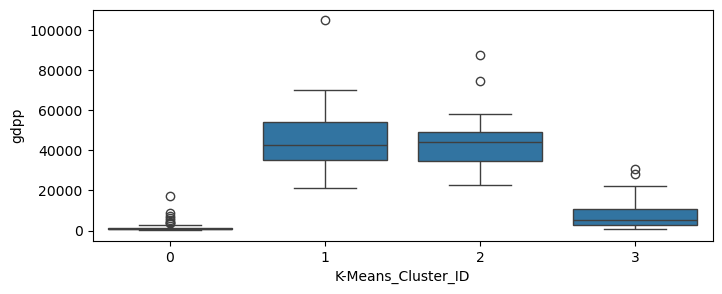

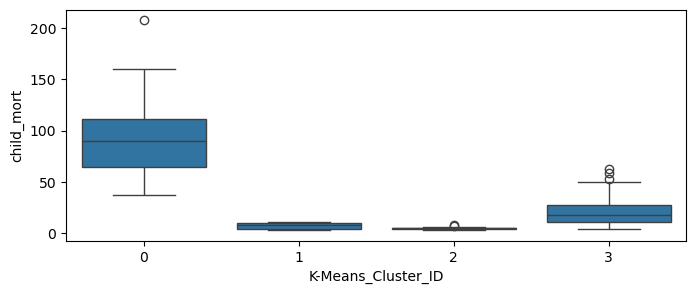

In [485]:
plt.figure(figsize=(8,3))
sns.boxplot(x='K-Means_Cluster_ID', y='gdpp', data=df)
plt.figure(figsize=(8,3))
sns.boxplot(x='K-Means_Cluster_ID', y='child_mort', data=df);

**Задание 7.9**


Итак, мы понимаем, что именно в выбранном нами кластере находятся страны, которые особенно остро нуждаются в финансовой помощи. Однако на все страны у нас не хватит ресурсов, поэтому давайте выберем из выделенного кластера три страны, в которых самая маленькая продолжительность жизни.

In [484]:
# Задание 7.9

K_Means_countries = df[df['K-Means_Cluster_ID'] == 0]
K_Means_countries.sort_values(by = 'life_expec')

,country,child_mort,exports,health,imports,income,inflation,life_expec,total_fer,gdpp,K-Means_Cluster_ID
66,Haiti,208.0,15.300,6.91,64.7000,1500,5.450,32.1,3.33,662,0
87,Lesotho,99.7,39.400,11.10,101.0000,2380,4.150,46.5,3.30,1170,0
31,Central African Republic,149.0,11.800,3.98,26.5000,888,2.010,47.5,5.21,446,0
166,Zambia,83.1,37.000,5.89,30.9000,3280,14.000,52.0,5.40,1460,0
94,Malawi,90.5,22.800,6.59,34.9000,1030,12.100,53.1,5.31,459,0
137,South Africa,53.7,28.600,8.94,27.4000,12000,6.350,54.3,2.59,7280,0
106,Mozambique,101.0,31.500,5.21,46.2000,918,7.640,54.5,5.56,419,0
132,Sierra Leone,160.0,16.800,13.10,34.5000,1220,17.200,55.0,5.20,399,0
64,Guinea-Bissau,114.0,14.900,8.50,35.2000,1390,2.970,55.6,5.05,547,0
0,Afghanistan,90.2,10.000,7.58,44.9000,1610,9.440,56.2,5.82,553,0
